### Finite time survival probability
$$\frac{\partial}{\partial t}\phi(u,t) = c\frac{\partial}{\partial u}\phi(u,t)-\lambda\phi(u,t) +\lambda\int_0^u\phi(u-x,t)p(x)dx $$

### Pareto clame size:
$$p(x;k,r) = \frac{kr^k}{x^{k+1}},~x>r$$



### 1. Import necessary packages and set problem specific data
This code runs with TensorFlow version `2.4.1`.
The implementation relies mainly on the scientific computing library [NumPy] and the machine learning library [TensorFlow].

In [1]:
# Import TensorFlow and NumPy
import tensorflow as tf
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import math

# Set data type
DTYPE='float64'
tf.keras.backend.set_floatx(DTYPE)

def p(x):
    p = k*r**k/x**(k+1)
    return(p)

# Define initial condition
def fun(n):
    sum=1
    for i in range(1,n+1):
        sum*=i
    return sum

def fun_u_0(x):
    n = x.shape[0]
    return tf.ones((n,1), dtype=DTYPE)



# Define residual of the PDE
def fun_r(t, x, u, u_t, u_x,u_int):
    return u_t -c*u_x +pois*u -pois*u_int

In [2]:
# Set number of data points
N_0 = 30
N_r = 100

# Set boundary
tmin = 0.
tmax = 10.
xmin = 0.
xmax = 10.

# Lower bounds
lb = tf.constant([tmin, xmin], dtype=DTYPE)
# Upper bounds
ub = tf.constant([tmax, xmax], dtype=DTYPE)

# Set random seed for reproducible results
np.random.seed(1)
#tf.random.set_seed(0)

# Draw uniform sample points for initial boundary data
t_0 = tf.ones((N_0,1), dtype=DTYPE)*lb[0]
x_0 = tf.reshape(tf.linspace(lb[1], ub[1], N_0),[N_0,1])
X_0 = tf.concat([t_0, x_0], axis=1)

# Evaluate intitial condition at x_0
u_0 = fun_u_0(x_0)

t_r = tf.random.uniform((N_r,1), lb[0], ub[0], dtype=DTYPE)

x_r = tf.random.uniform((N_r,1), lb[1], ub[1], dtype=DTYPE)

X_r = tf.concat([t_r, x_r], axis=1)

X_data = [X_0]
u_data = [u_0]

2023-03-22 11:37:13.964277: I tensorflow/core/platform/cpu_feature_guard.cc:145] This TensorFlow binary is optimized with Intel(R) MKL-DNN to use the following CPU instructions in performance critical operations:  SSE4.1 SSE4.2
To enable them in non-MKL-DNN operations, rebuild TensorFlow with the appropriate compiler flags.
2023-03-22 11:37:13.964680: I tensorflow/core/common_runtime/process_util.cc:115] Creating new thread pool with default inter op setting: 8. Tune using inter_op_parallelism_threads for best performance.


Next, we illustrate the collocation points (red circles) and the positions where the boundary and initial conditions will be enforced (cross marks, color indicates value).

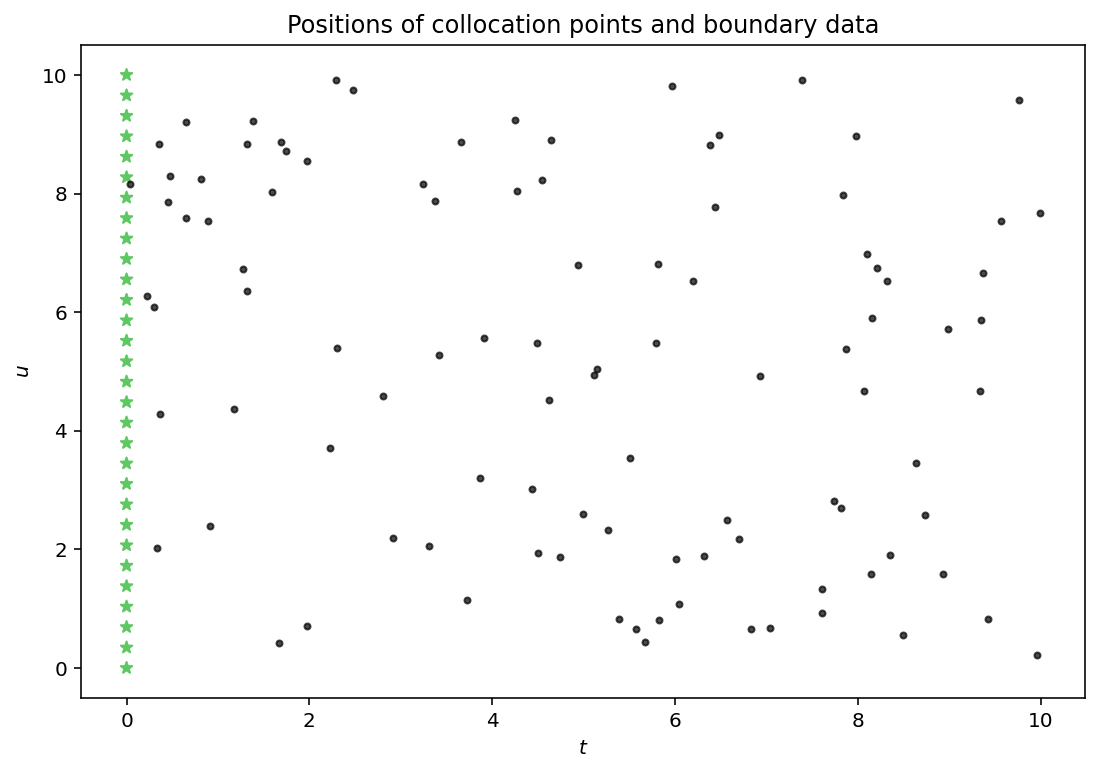

In [3]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
fig = plt.figure(figsize=(9,6))
plt.scatter(t_0, x_0, c=u_0, marker='*', vmin=-2, vmax=2)
#plt.scatter(t_b, x_b, c=u_b, marker='x', vmin=-2, vmax=2)
plt.scatter(t_r, x_r, c='black', marker='.', alpha=0.7)
plt.xlabel('$t$')
plt.ylabel('$u$')

plt.title('Positions of collocation points and boundary data');
plt.savefig('Xdata.png', bbox_inches='tight', dpi=300)

In [4]:
def init_model(num_hidden_layers=4, num_neurons_per_layer=8):
    
    # Initialize a feedforward neural network
    model = tf.keras.Sequential()

    # Input is two-dimensional (time + one spatial dimension)
    model.add(tf.keras.Input(2))

    # Introduce a scaling layer to map input to [lb, ub]
    scaling_layer = tf.keras.layers.Lambda(
                lambda x: 2.0*(x - lb)/(ub - lb) - 1.0)
    model.add(scaling_layer)

    # Append hidden layers
    for _ in range(num_hidden_layers):
        model.add(tf.keras.layers.Dense(num_neurons_per_layer,
            activation=tf.keras.activations.get('tanh'),
            kernel_initializer='glorot_normal'))

    # Output is one-dimensional
    model.add(tf.keras.layers.Dense(1))
    
    return model

In [5]:
def get_r(model, X_r,data_intx,data_intt,data_intp):
    
    # A tf.GradientTape is used to compute derivatives in TensorFlow
    with tf.GradientTape(persistent=True) as tape:
        # Split t and x to compute partial derivatives
        t, x = X_r[:, 0:1], X_r[:,1:2]

        # Variables t and x are watched during tape
        # to compute derivatives u_t and u_x
        tape.watch(t)
        tape.watch(x)

        # Determine residual 
        u = model(tf.stack([t[:,0], x[:,0]], axis=1))
        
        
        u_int = np.zeros((N_r,1))
        for i in range(N_r):
            u_int[i] = (tf.reduce_sum(model(tf.stack([data_intt[:,i], data_intx[:,i]], 
                                                    axis=1))*(tf.reshape(data_intp[:,i],[Ndx,1]))*dx)+
            tf.reduce_sum(model(tf.stack([data_intt[1:-1,i], data_intx[1:-1,i]],
                                         axis=1))*(tf.reshape(data_intp[1:-1,i],[Ndx-2,1]))*dx)+
            2*tf.reduce_sum(model(tf.stack([data_intt[1:-1:2,i], data_intx[1:-1:2,i]],
                                         axis=1))*(tf.reshape(data_intp[1:-1:2,i],
                                                              [len(data_intt[1:-1:2,i]),1]))*dx))/3
            
        u_int = tf.convert_to_tensor(u_int)
        
        # Compute gradient u_x within the GradientTape
        # since we need second derivatives
        u_x = tape.gradient(u, x)
        
    u_t = tape.gradient(u, t)


    #del tape

    return fun_r(t, x, u, u_t, u_x,u_int)

In [6]:
def compute_loss(model, X_r, X_data, u_data,data_intx,data_intt,data_intp):
    
    # Compute phi^r
    r = get_r(model, X_r,data_intx,data_intt,data_intp)
    phi_r = tf.reduce_mean(tf.square(r))
    
    # Initialize loss
    loss = phi_r
    
    # Add phi^0 and phi^b to the loss
    for i in range(len(X_data)):
        u_pred = model(X_data[i])
        loss += tf.reduce_mean(tf.square(u_data[i] - u_pred))
    
    return loss

In [7]:
def get_grad(model, X_r, X_data, u_data,data_intx,data_intt,data_intp):
    
    with tf.GradientTape(persistent=True) as tape:
        # This tape is for derivatives with
        # respect to trainable variables
        tape.watch(model.trainable_variables)
        loss = compute_loss(model, X_r, X_data, u_data,data_intx,data_intt,data_intp)

    g = tape.gradient(loss, model.trainable_variables)
    del tape

    return loss, g

In [8]:
# Initialize model aka u_\theta
model = init_model()

# We choose a piecewise decay of the learning rate, i.e., the
# step size in the gradient descent type algorithm
# the first 1000 steps use a learning rate of 0.01
# from 1000 - 3000: learning rate = 0.001
# from 3000 onwards: learning rate = 0.0005

lr = tf.keras.optimizers.schedules.PiecewiseConstantDecay([1000,3000],[1e-2,1e-3,5e-4])

# Choose the optimizer

optim = tf.keras.optimizers.Adam(learning_rate=lr)

In [9]:
# Define one training step as a TensorFlow function to increase speed of training
# @tf.function
def train_step():
    # Compute current loss and gradient w.r.t. parameters
    loss, grad_theta = get_grad(model, X_r, X_data, u_data,data_intx,data_intt,data_intp)
    
    # Perform gradient descent step
    optim.apply_gradients(zip(grad_theta, model.trainable_variables))
    
    return loss

In [10]:
from time import time
warnings.filterwarnings("ignore")

# Set constants
c_ = np.array([1.21, 1.98])
pois_ = np.array([1, 1.5])

k_ = np.array([1.1, 1.2])
r_ = np.array([0.1,0.2])
# r = np.array(r)[0]

num_hidden_layers = 4
num_neurons_per_layer = 8
length = len(c_)

# Initialize model aka u_\theta
model = init_model(num_hidden_layers, num_neurons_per_layer)

# We choose a piecewise decay of the learning rate, i.e., the
# step size in the gradient descent type algorithm
# the first 1000 steps use a learning rate of 0.01
# from 1000 - 3000: learning rate = 0.001
# from 3000 onwards: learning rate = 0.0005

lr = tf.keras.optimizers.schedules.PiecewiseConstantDecay([1000,3000],[1e-2,1e-3,5e-4])

# Choose the optimizer

optim = tf.keras.optimizers.Adam(learning_rate=lr)

In [11]:
def phi(t,u):
    X_i = np.array([[t,u]])
    Phi_pred = model(tf.convert_to_tensor(X_i))
    Phi = np.array(Phi_pred)
    return Phi

In [12]:
for o in range(length):
    c = c_[o]
    pois = pois_[o]
    
    k = k_[o]
    r = r_[o]
    
    dx = 0.05
    Ndx = int(xmax/dx)
    data_intx = np.zeros((Ndx,N_r))
    data_intt = tf.tile(t_r, (1,Ndx))
    data_intt = tf.transpose(data_intt)
    data_intp = np.zeros((Ndx,N_r)) 

    px = np.zeros((Ndx,1))
    for i in range(Ndx):
        px[i] = p(i * dx)


    for j in range(N_r):
        data_intx[:,j] = np.concatenate(
            [x_r[j].numpy()-np.linspace(0,x_r[j].numpy(),math.ceil(x_r[j]/dx)),
             np.linspace(0,0,Ndx-math.ceil(x_r[j]/dx)).reshape(Ndx-math.ceil(x_r[j]/dx),
                                                                1)],axis = 0 ).reshape(Ndx)
        data_intp[:,j] = np.concatenate([px[0:math.ceil(x_r[j]/dx)],
                                         np.zeros((Ndx-math.ceil(x_r[j]/dx),1))],axis = 0).reshape(Ndx) 
    data_intx = tf.convert_to_tensor(data_intx)
    data_intp = tf.convert_to_tensor(data_intp)
    
    print('当c=',c,'，pois=',pois,'时：')
    
    # Number of training epochs
    N = 50000
    hist = []

    # Start timer
    t0 = time()
    
    for i in range(N+1):

        loss = train_step()

        # Append current loss to hist
        hist.append(loss.numpy())

        if i%100 == 0:
            print('It = {:05d}| loss = {:10.8e}'.format(i,loss),'| progress report:' '%.2f%%' %(i/N*100))
        if loss <= 1e-3:
            print('It = {:05d}| loss = {:10.8e}'.format(i,loss),'| progress report:' '%.2f%%' %(i/N*100))
            break
        
    # Print computation time
    print('\nComputation time: {} seconds'.format(time()-t0))
    
    u = [0.0, 1.0, 2.0, 5.0, 10.0]
    t = [1.0, 3.0, 5.0, 7.0, 9.0, 10.0]
    pred = np.full((len(u),len(t)),0.0)
    for m in range(len(u)):
        for n in range(len(t)):
            pred[m][n] = phi(t[n], u[m])[0][0]
    print(pred)

当c= 1.21 ，pois= 1.0 时：
It = 00000| loss =        inf | progress report:0.00%


KeyboardInterrupt: 

### Plot solution

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Set up meshgrid
N = 100
tspace = np.linspace(0, ub[0], N + 1)
xspace = np.linspace(0, ub[1], N + 1)
surface = np.zeros((N+1, N+1))

T, X = np.meshgrid(tspace, xspace)
Xgrid = np.vstack([T.flatten(),X.flatten()]).T


upred = model(tf.cast(Xgrid,DTYPE))

U = upred.numpy().reshape(N+1,N+1)
for i, x in enumerate(xspace):
    for j, y in enumerate(tspace):
        surface[i][j] = phi(x, y)

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')
ax.w_xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.w_yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.w_zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
surf = ax.plot_surface(T, X, U,cmap='viridis');
ax.view_init(15,-35)
ax.set_xlabel('$t$')
ax.set_ylabel('$u$')
ax.set_zlabel('$\\phi_\\theta(u,t)$')
fig.colorbar(surf, shrink=0.5, aspect=10)


In [ ]:
u_data

In [ ]:
for i in range(len(X_data)):
    u_pred = model(X_data[i])
    print(u_pred)